# 逻辑回归: 分类算法

## 1.1简介

### 1.1线性分类

线性分类，本质上就是使用一条线来对样本进行分类

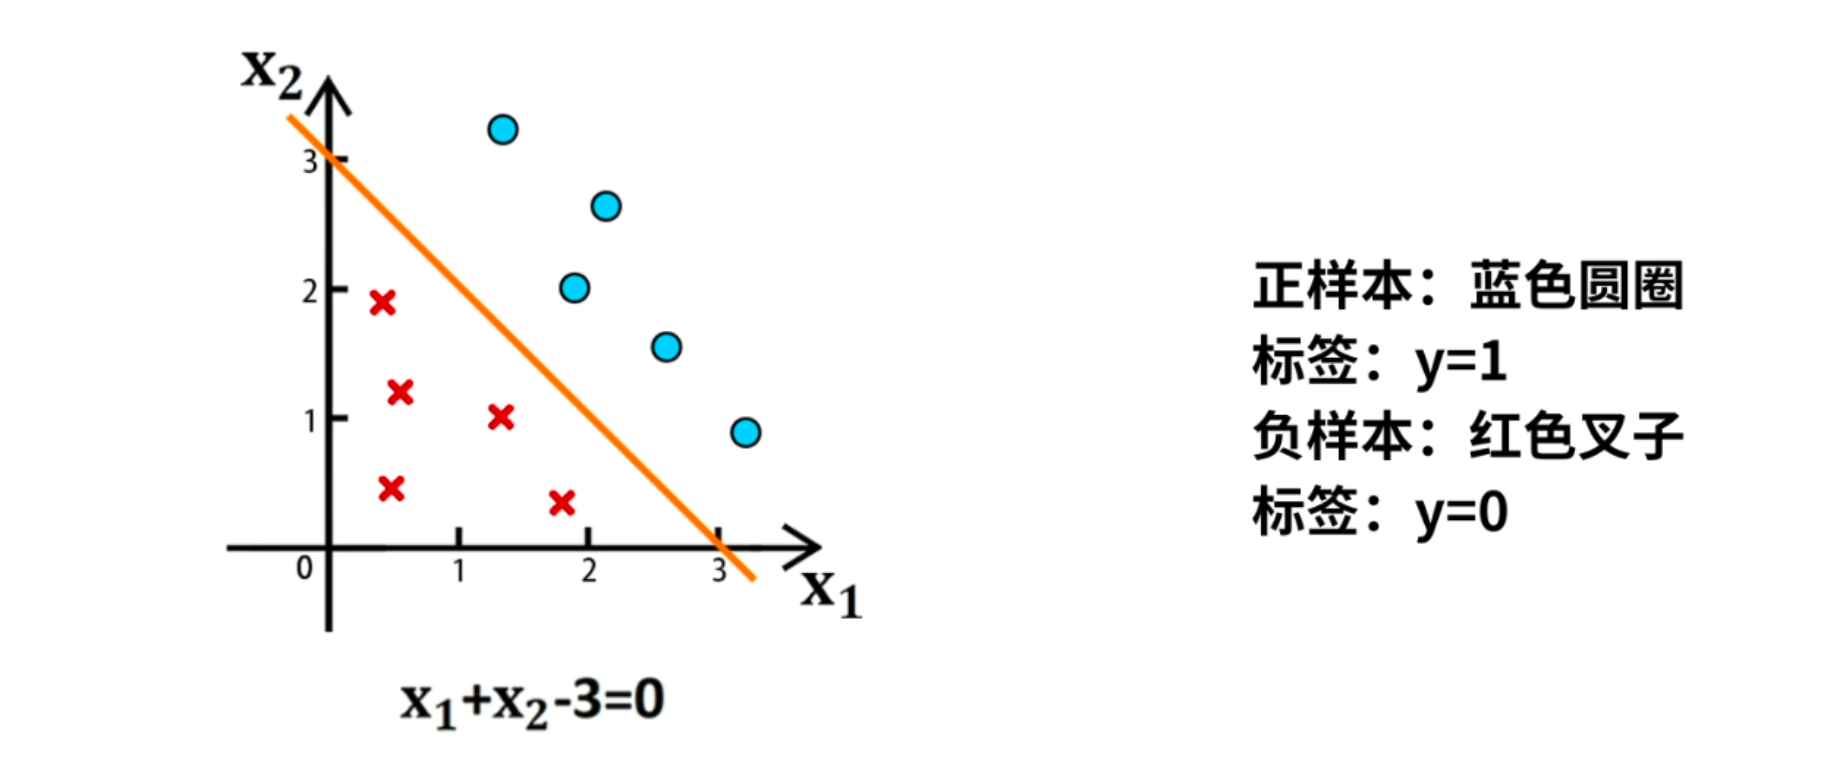

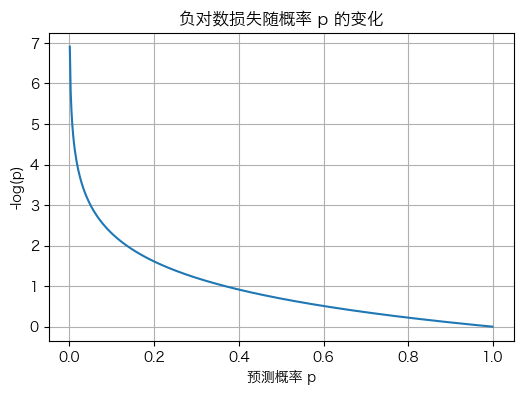

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 生成 0~1 之间的概率值（避开 0 和 1 防止 log(0)）
p = np.linspace(0.001, 0.999, 500)

# 计算负对数损失：-log(p)
loss = -np.log(p)

# 绘制曲线
#添加中文字体
plt.rcParams['font.sans-serif'] = ['Hiragino Sans GB']
plt.figure(figsize=(6, 4))
plt.plot(p, loss, color='tab:blue')
plt.xlabel('预测概率 p')
plt.ylabel('-log(p)')
plt.title('负对数损失随概率 p 的变化')
plt.grid(True)
plt.show()


## 逻辑回归实战

In [ ]:
import pandas as pd
# 导入必要库：数据拆分、预处理（标准化/编码/插补）、模型与评估
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 读取乳腺癌数据集 CSV；常见包含诊断列(diagnosis)、患者id以及各类数值/类别特征
file_path = '/Users/white/Desktop/Code/MacCode-master/PYproject/pythonProject/prime/4.算法/data/Breast-Cancer-Wisconsin.csv'
df = pd.read_csv(file_path)

# 选择标签列：若存在 diagnosis 列则优先使用，否则回退到最后一列（提高稳健性）
label_col = 'diagnosis' if 'diagnosis' in df.columns else df.columns[-1]
# 特征集：移除标签列与无用的 id 列；删除整列为空的列以避免 NaN 造成训练报错
X = df.drop(columns=[label_col, 'id'], errors='ignore')
X = X.dropna(axis=1, how='all')
# 原始标签通常为字符串（如 M/B），用 LabelEncoder 编码为 0/1 的一维数组
y = df[label_col]
le = LabelEncoder()
y = le.fit_transform(y)

# 将类别型特征做独热编码，避免字符串进入模型；保留数值列原样供后续插补/标准化
X = pd.get_dummies(X, drop_first=True)
# 使用中位数插补缺失值，鲁棒于异常值；得到纯数值矩阵
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
# 标准化至零均值单位方差，利于逻辑回归优化收敛与系数可比性
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 按 8:2 划分训练/测试集；固定随机种子以复现实验结果
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 训练逻辑回归模型；提高 max_iter 以避免在复杂特征下出现收敛警告
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 预测测试集标签
y_pred = model.predict(X_test)

# 输出分类报告（precision/recall/f1）与整体准确率，评估模型分类性能
print("分类报告：")
print(classification_report(y_test, y_pred))
print("准确率：", accuracy_score(y_test, y_pred))


分类报告：
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

准确率： 0.9736842105263158
